<a href="https://colab.research.google.com/github/JaniceShirley/ML_Basics/blob/main/DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Data Wrangling is the process of cleaning, transforming, and organizing
raw data into a structured and usable format.
It involves handling missing values, correcting errors, and preparing data for analysis.

In [8]:
import pandas as pd

data = {
    "name": ["Alice", "Bob", None],
    "age": [10, None, 16]
}

df = pd.DataFrame(data)
print(df)

    name   age
0  Alice  10.0
1    Bob   NaN
2   None  16.0


In [1]:
"""
# 1----dropna()-----Remove rows and col with missing values

df_drop=df.dropna(axis=1)
print(df_drop)
"""

'\n# 1----dropna()-----Remove rows and col with missing values\n\ndf_drop=df.dropna(axis=1)\nprint(df_drop)\n'

In [11]:
"""
# 2----fillna()---FILL missing values
df = pd.DataFrame(data)
print(df)
df_fill=df.fillna({
    "name":"unknown",
    "age":df["age"].mean()
})
print(df_fill)
"""


    name   age
0  Alice  10.0
1    Bob   NaN
2   None  16.0
      name   age
0    Alice  10.0
1      Bob  13.0
2  unknown  16.0


In [ ]:
##MERGE vs CONCAT

In [17]:

# 🔵1 merge() → Combine datasets using a common column (key)
import pandas as pd
df1 = pd.DataFrame({
     "ID": [1, 2, 3],
     "Name": ["Alice", "Bob", "Charlie"]
})

df2 = pd.DataFrame({
    "ID": [1, 2, 4],
    "Score": [85, 90, 75]
})
merged=pd.merge(df1,df2,on="ID",how="right")
print(merged)
# id 3 and 4 r removed

   ID   Name  Score
0   1  Alice     85
1   2    Bob     90
2   4    NaN     75


In [ ]:
##Type of merge
1.Inner(default)
2.Outer-------how="outer"
3.left-------how="left"
4.right-------how="right"

In [19]:

#🟢2 concat()-----Stacked one below another
import pandas as pd
df1 = pd.DataFrame({
    "Name": ["Alice", "Bob"]
})

df2 = pd.DataFrame({
    "Name": ["Charlie", "David"]
})
concate=pd.concat([df1,df2],axis=1)
# axis=1 joins side-by-side
print(concate)

    Name     Name
0  Alice  Charlie
1    Bob    David


In [27]:
#🟡 3. join() → Merge using index instead of column

import pandas as pdArithmeticError
df1 = pd.DataFrame({"Name": ["Alice", "Bob"]}, index=[1,2])
df2 = pd.DataFrame({"Score": [85, 90]}, index=[1,3])
joined=df1.join(df2)
print(joined)


    Name  Score
1  Alice   85.0
2    Bob    NaN


In [29]:
##🔴 4. combine_first() → Fill missing using another dataset

import pandas as pd
df1 = pd.DataFrame({
    "Name": ["Alice", None],
    "Score": [85, None]
})

df2 = pd.DataFrame({
    "Name": ["Unknown", "Bob"],
    "Score": [90, 95]
})
combined=df1.combine_first(df2)
print(combined)

    Name  Score
0  Alice   85.0
1    Bob   95.0


In [ ]:
###    RESHAPING (Pivot)-------Changing the structure of data (rows ↔ columns)

import pandas as pd
data = {
    "Date": ["2024-01-01", "2024-01-01", "2024-01-02"],
    "City": ["NY", "LA", "NY"],
    "Sales": [100, 200, 150]
}
df = pd.DataFrame(data)
print(df)

In [ ]:
#RESHAPING (Pivot) & DATA TRANSFORMATION & STANDRADIZATION

In [2]:
"""
#RESHAPING (Pivot)
Changing the structure of data (rows ↔ columns)
It reorganizes data based on 3 things:-------pivot(index=..., columns=..., values=...)
"""
import pandas as pd
data = {
    "Date": ["2024-01-01", "2024-01-01", "2024-01-02"],
    "City": ["NY", "LA", "NY"],
    "Sales": [100, 200, 150]
}
df = pd.DataFrame(data)
print(df)
pivot=df.pivot(index="Date",columns="City",values="Sales")
print(pivot)


         Date City  Sales
0  2024-01-01   NY    100
1  2024-01-01   LA    200
2  2024-01-02   NY    150
City           LA     NY
Date                    
2024-01-01  200.0  100.0
2024-01-02    NaN  150.0


In [ ]:
🧠 Understanding

👉 Rows → Date
👉 Columns → City
👉 Values → Sales

In [ ]:
#2. DATA TRANSFORMATION------Modify data to make it useful
Data transformation is the process of modifying data into a suitable format
by creating new columns, changing values, converting data types, and restructuring data.
---Transformation = change data, not add new data

In [11]:
#2. DATA TRANSFORMATION
import pandas as pd
df = pd.DataFrame({
    "Age": [20, 35, 50]
})
print(df)
# create new column named agegroup
df["agegroup"]=df["Age"].apply(lambda x: "young" if x<30 else "old")
print(df)
#Modify existing value
df["Age"] = df["Age"] * 2
print(df)
#change datatypes
df["Age"]=df["Age"].astype(float)
print(df)

   Age
0   20
1   35
2   50
   Age agegroup
0   20    young
1   35      old
2   50      old
   Age agegroup
0   40    young
1   70      old
2  100      old
     Age agegroup
0   40.0    young
1   70.0      old
2  100.0      old


In [ ]:
# 3. STANDARDIZATION ------Convert continuous data → categories
Has 2 types
1. Binning
2. Normalization

In [13]:
# STANDARDIZATION / BINNING
df = pd.DataFrame({
    "Age": [18, 25, 35, 45, 60]
})
df["agegroup"]=pd.cut(df["Age"], bins=[0,25,60,100],labels=["young","medium","old"])
print(df)


   Age agegroup
0   18    young
1   25    young
2   35   medium
3   45   medium
4   60   medium


In [15]:
# STANDARDIZATION / Normalization-------Convert values into range (usually 0 to 1)
df = pd.DataFrame({
    "Marks": [40, 60, 80, 100]
})
df["Marks_norm"] = (df["Marks"]-df["Marks"].min())/(df["Marks"].max()-df["Marks"].min())
#normalization=(value - min) / (max - min)
print(df)

   Marks  Marks_norm
0     40    0.000000
1     60    0.333333
2     80    0.666667
3    100    1.000000


In [ ]:
🔴 Outliers / Noise / Anomalies
# Outliers or Anomaly = value that is very different from other values in dataset

✅ 2. Why they are important
* Can affect accuracy of analysis
* Can give wrong results (mean, model)
* May represent errors or rare events

✅ 3. Types (just basic idea)
* Outliers → extreme values
* Noise → random errors
* Anomalies → unusual patterns

✅ 4. Detection Methods
✔ Method 1: Statistical (IQR)
       IQR = Q3 − Q1

          Lower = Q1 − 1.5 × IQR
          Upper = Q3 + 1.5 × IQR
✔ Method 2: Visualization
* Boxplot

✅ 5. Handling Outliers
1. Remove outliers
2. Replace values (mean/median)
3. Keep them if important

In [19]:
###✔ Method 1: Statistical (IQR)
import pandas as pd
df = pd.DataFrame({
    "Marks": [40, 45, 50, 48, 47, 2]
})
print(df)
Q1=df["Marks"].quantile(0.25)
Q3=df["Marks"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outlier=df[(df["Marks"]<lower)|(df["Marks"]>upper)]
print("outlier")
print(outlier)

   Marks
0     40
1     45
2     50
3     48
4     47
5      2
outlier
   Marks
5      2


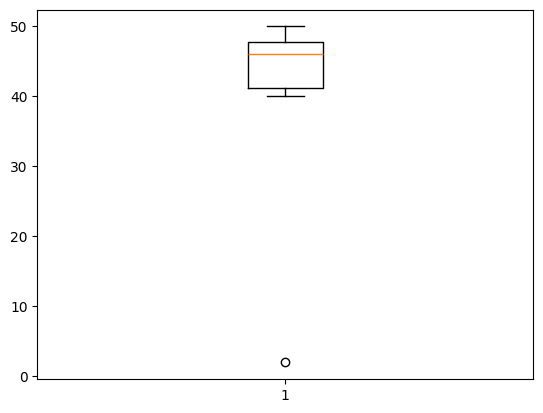

In [21]:
## Method 2----boxplot
import matplotlib.pyplot as plt
import pandas as pd
df = pd.DataFrame({
    "Marks": [40, 45, 50, 48, 47, 2]
})
plt.boxplot(df["Marks"])
plt.show()

In [ ]:
🧠 What is Matplotlib?
Matplotlib is a Python library used to create graphs and visualizations from data.
👉 Raw data (numbers) is hard to understand ❌
👉 Graphs make it easy ✔

🔹 What can Matplotlib do?

It can create:

* 📈 Line plots → trends
* 📊 Scatter plots → relationships
* 📉 Histograms → distribution
* 📦 Boxplots → outliers

🔸 PYPLOT
👉 Most used part of Matplotlib
👉 Used to:

* create plots
* show graphs
* customize

In [ ]:
#LINE PLOT
A line plot is used to represent data points connected by straight lines,
showing trends over time or sequence.
It is commonly used for continuous data visualization.

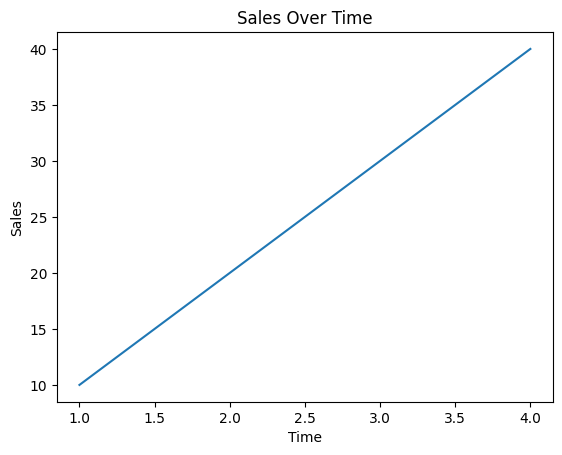

In [23]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = [10, 20, 30, 40]

plt.plot(x, y)
plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Sales Over Time")
plt.show()

In [ ]:
#Scatter Plot
A scatter plot shows the relationship between two variables using points.
A scatter plot represents data points as dots to show the relationship between two variables.
It helps identify patterns such as positive, negative, or no correlation.

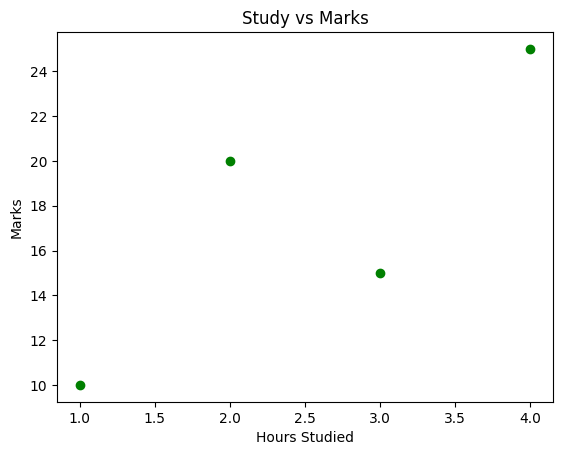

In [26]:
import matplotlib.pyplot as plt
x = [1, 2, 3, 4]
y = [10, 20, 15, 25]
plt.scatter(x, y, color="green")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Study vs Marks")
plt.show()

In [ ]:
#📉 HISTOGRAM
A histogram shows the distribution of data by grouping values into ranges (bins)
* X-axis → value ranges (bins)
* Y-axis → frequency (how many values)
* Bars → number of values in each range

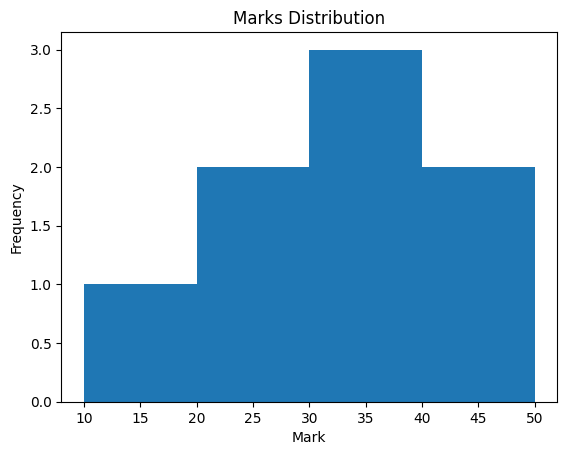

In [33]:
import matplotlib.pyplot as plt
data = [10, 20, 20, 30, 30, 30, 40, 50]
plt.hist(data,bins=4)
plt.xlabel("Mark")
plt.ylabel("Frequency")
plt.title("Marks Distribution")
plt.show()

In [ ]:
#📦 BOXPLOT
A boxplot shows data distribution and helps detect outliers

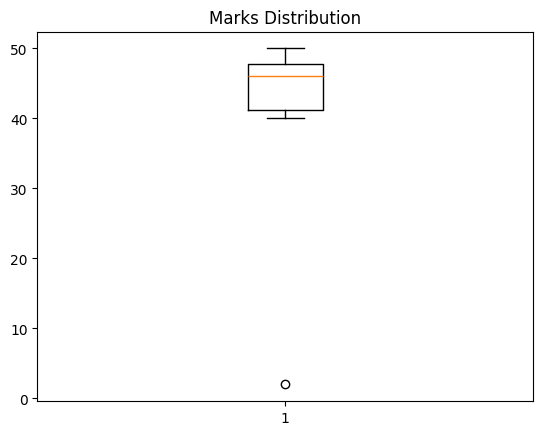

In [35]:
import matplotlib.pyplot as plt
data = [40, 45, 50, 48, 47, 2]
plt.boxplot(data)
plt.title("Marks Distribution")
plt.show()
#40, 45, 47, 48, 50 → normal--------2 → anomaly

In [ ]:
#SUBPLOT
Subplots = multiple graphs in a single figure (screen)

🎯 Why use subplots?
* Compare graphs
* Save space
* View multiple results together

🔹 Syntax---------plt.subplot(rows, columns, position)

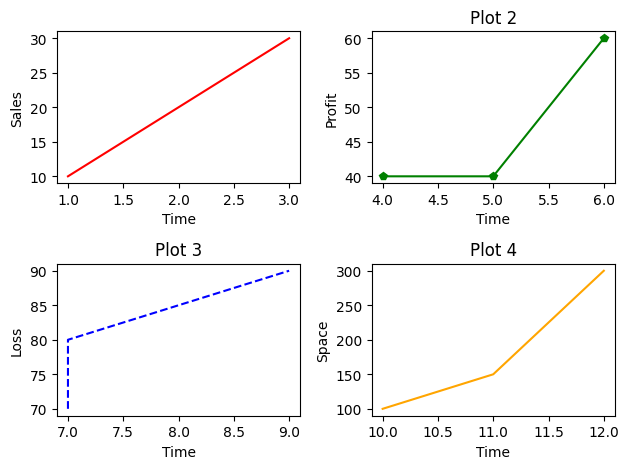

In [46]:
import matplotlib.pyplot as plt
plt.subplot(2,2,1)
plt.plot([1,2,3], [10,20,30], color="red")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Plot 1")
plt.subplot(2,2,2)
plt.plot([4,5,6], [40,40,60], color="green", marker="p")
plt.xlabel("Time")
plt.ylabel("Profit")
plt.title("Plot 2")
plt.subplot(2,2,3)
plt.plot([7,7,9], [70,80,90], color="blue", linestyle='--')
plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Plot 3")
plt.subplot(2,2,4)
plt.plot([10,11,12], [100,150,300], color="orange")
plt.xlabel("Time")
plt.ylabel("Space")
plt.title("Plot 4")
plt.tight_layout()
plt.show()

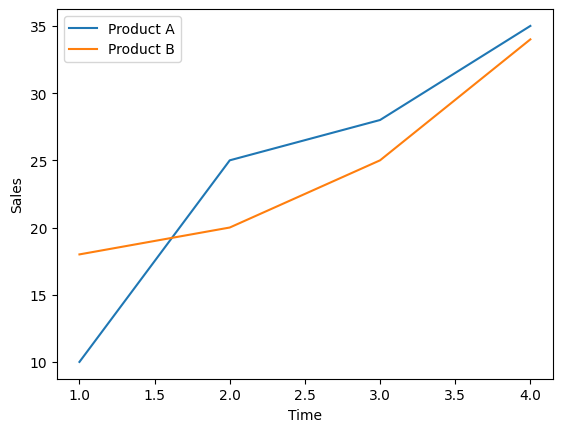

In [49]:
##LEGEND-----Wht color line represents wht -----the upper box
import matplotlib.pyplot as plt
x=[1,2,3,4]
y1=[10,25,28,35]
y2=[18,20,25,34]
plt.plot(x, y1, label="Product A")
plt.plot(x, y2, label="Product B")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

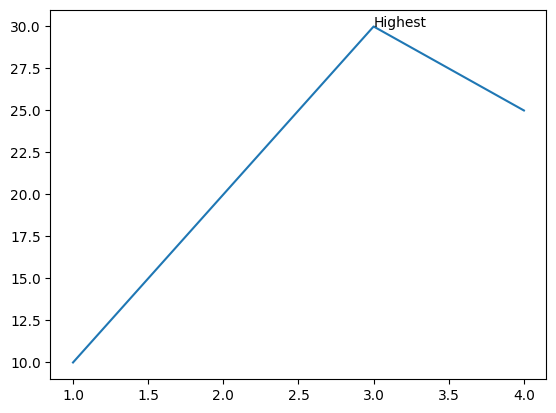

In [52]:
##Annotation

import matplotlib.pyplot as plt
x = [1,2,3,4]
y = [10,20,30,25]
y_max=max(y)
index=y.index(y_max)
x_max=x[index]
plt.plot(x, y)
plt.annotate("Highest", xy=(x_max,y_max))
plt.show()

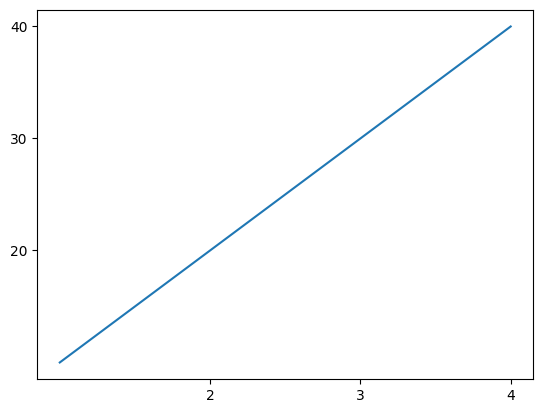

In [53]:
###Ticks

import matplotlib.pyplot as plt
x = [1,2,3,4]
y = [10,20,30,40]
plt.plot(x, y)
plt.xticks([2,3,4])      # x-axis ticks
plt.yticks([20,30,40])  # y-axis ticks
plt.show()